# MNIST Binary Classification - K-Nearest Neighbors

## Complete Pipeline: Data Loading → Preprocessing → Training → Evaluation

This notebook contains the complete end-to-end pipeline for K-Nearest Neighbors.

## 1. Import Libraries

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [2]:
# Binary classification configuration
DIGIT_A = 0
DIGIT_B = 1

# Data split configuration
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# PCA configuration
PCA_COMPONENTS = 50

# KNN hyperparameters
K_NEIGHBORS = 5

print(f"Configuration:")
print(f"  Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"  Train/Val/Test Split: {TRAIN_SIZE:.0%}/{VAL_SIZE:.0%}/{TEST_SIZE:.0%}")
print(f"  PCA Components: {PCA_COMPONENTS}")
print(f"  K Neighbors: {K_NEIGHBORS}")

Configuration:
  Binary Classification: Digit 0 vs Digit 1
  Train/Val/Test Split: 70%/15%/15%
  PCA Components: 50
  K Neighbors: 5


## 3. Load MNIST Dataset

In [3]:
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

# Load training data from .npy files
X_train_raw = np.load('../mnist.npz/x_train.npy')
y_train_raw = np.load('../mnist.npz/y_train.npy')

# Load test data from .npy files
X_test_raw = np.load('../mnist.npz/x_test.npy')
y_test_raw = np.load('../mnist.npz/y_test.npy')

print(f"Training data shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Test data shape: X={X_test_raw.shape}, y={y_test_raw.shape}")
print("\n✓ Data loaded successfully")

LOADING DATA
Training data shape: X=(60000, 28, 28), y=(60000,)
Test data shape: X=(10000, 28, 28), y=(10000,)

✓ Data loaded successfully


## 4. Visualize Sample MNIST Images

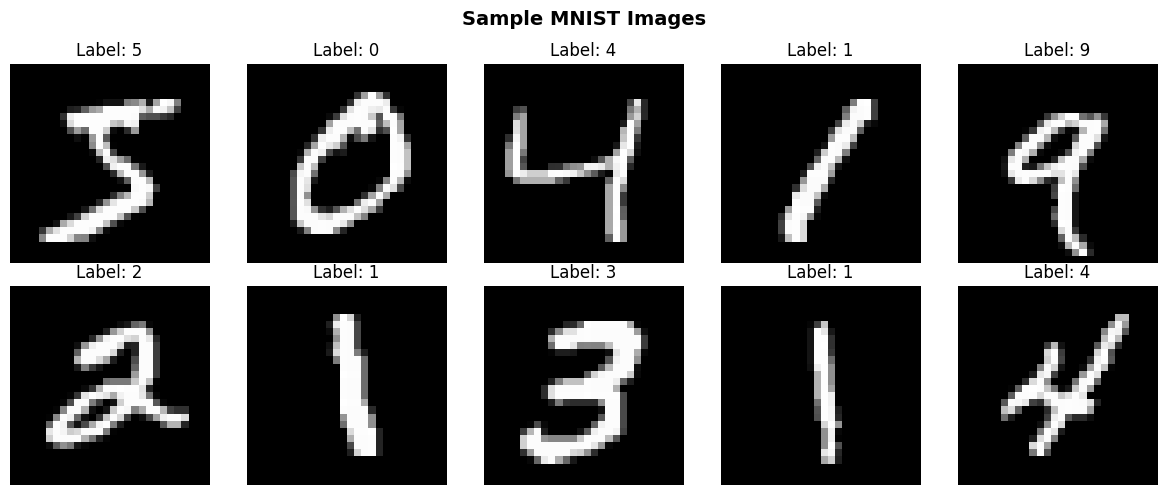

In [4]:
# Display sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train_raw[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_raw[i]}')
    axes[i].axis('off')

plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Filter Binary Classes

In [5]:
print("=" * 70)
print(f"FILTERING BINARY CLASSES: {DIGIT_A} vs {DIGIT_B}")
print("=" * 70)

# Filter training data for selected digits
train_mask = (y_train_raw == DIGIT_A) | (y_train_raw == DIGIT_B)
X_train_filtered = X_train_raw[train_mask]
y_train_filtered = y_train_raw[train_mask]

# Filter test data for selected digits
test_mask = (y_test_raw == DIGIT_A) | (y_test_raw == DIGIT_B)
X_test_filtered = X_test_raw[test_mask]
y_test_filtered = y_test_raw[test_mask]

# Convert labels to binary (0 and 1)
y_train_binary = (y_train_filtered == DIGIT_B).astype(int)
y_test_binary = (y_test_filtered == DIGIT_B).astype(int)

print(f"Filtered training dataset size: {len(X_train_filtered)}")
print(f"Class distribution: {DIGIT_A}={np.sum(y_train_binary == 0)}, {DIGIT_B}={np.sum(y_train_binary == 1)}")
print("\n✓ Binary classes filtered")

FILTERING BINARY CLASSES: 0 vs 1
Filtered training dataset size: 12665
Class distribution: 0=5923, 1=6742

✓ Binary classes filtered


## 6. Image Normalization

In [6]:
print("=" * 70)
print("IMAGE NORMALIZATION")
print("=" * 70)

# Normalize pixel values to [0, 1] range
X_train_norm = X_train_filtered / 255.0
X_test_norm = X_test_filtered / 255.0

print(f"Pixel value range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
print("✓ Images normalized")

IMAGE NORMALIZATION
Pixel value range: [0.00, 1.00]
✓ Images normalized


## 7. Flatten Images

In [7]:
print("=" * 70)
print("FLATTENING IMAGES")
print("=" * 70)

# Flatten images from (28, 28) to (784,)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print(f"Training data shape after flattening: {X_train_flat.shape}")
print(f"Test data shape after flattening: {X_test_flat.shape}")
print("✓ Images flattened")

FLATTENING IMAGES
Training data shape after flattening: (12665, 784)
Test data shape after flattening: (2115, 784)
✓ Images flattened


## 8. Feature Standardization

In [8]:
print("=" * 70)
print("FEATURE STANDARDIZATION")
print("=" * 70)

# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print(f"Mean: {X_train_scaled.mean():.6f}")
print(f"Std: {X_train_scaled.std():.6f}")
print("✓ Features standardized")

FEATURE STANDARDIZATION
Mean: -0.000000
Std: 0.887124
✓ Features standardized


## 9. PCA Dimensionality Reduction

In [ ]:
print("=" * 70)
print(f"PCA DIMENSIONALITY REDUCTION (n_components={PCA_COMPONENTS})")
print("=" * 70)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=PCA_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Explained variance: {explained_variance:.4f} ({explained_variance*100:.2f}%)")
print(f"Training data shape after PCA: {X_train_pca.shape}")
print("✓ PCA applied")

PCA DIMENSIONALITY REDUCTION (n_components=50)


## 10. Train/Validation/Test Split

In [ ]:
print("=" * 70)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 70)

# Split training data into train and validation sets
val_ratio = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pca, y_train_binary, test_size=val_ratio, random_state=42, stratify=y_train_binary
)

# Test set is already separate
X_test = X_test_pca
y_test = y_test_binary

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")
print("✓ Data split complete")

## 11. K-Nearest Neighbors Implementation (From Scratch)

In [ ]:
# Implement K-Nearest Neighbors from scratch
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
    
    def euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance between two points"""
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict_single(self, x):
        """Predict class for a single sample"""
        # Calculate distances to all training samples
        distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get labels of k nearest neighbors
        k_nearest_labels = self.y_train[k_indices]
        
        # Return most common label (majority vote)
        return np.bincount(k_nearest_labels).argmax()
    
    def predict(self, X):
        """Predict classes for multiple samples"""
        predictions = [self.predict_single(x) for x in tqdm(X, desc="Predicting")]
        return np.array(predictions)

print("✓ KNN Classifier implemented")

## 12. Train KNN Model

In [ ]:
print("=" * 70)
print(f"TRAINING KNN MODEL (k={K_NEIGHBORS})")
print("=" * 70)

# Initialize and train KNN classifier
knn = KNNClassifier(k=K_NEIGHBORS)
knn.fit(X_train, y_train)

print("✓ KNN model trained (training data stored)")

## 13. Evaluate on Validation Set

In [ ]:
print("=" * 70)
print("VALIDATION SET EVALUATION")
print("=" * 70)

# Make predictions on validation set
y_val_pred = knn.predict(X_val)

# Calculate validation accuracy
val_accuracy = np.mean(y_val_pred == y_val)
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

## 14. Evaluate on Test Set

In [ ]:
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

# Make predictions on test set
y_test_pred = knn.predict(X_test)

# Calculate test accuracy
test_accuracy = np.mean(y_test_pred == y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

## 15. Classification Report

In [ ]:
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

# Generate classification report
print(classification_report(y_test, y_test_pred, target_names=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}']))

## 16. Confusion Matrix Visualization

In [ ]:
# Generate and visualize confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'],
            yticklabels=[f'Digit {DIGIT_A}', f'Digit {DIGIT_B}'])
plt.title('Confusion Matrix - KNN', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 17. Final Summary

In [ ]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Model: K-Nearest Neighbors (k={K_NEIGHBORS})")
print(f"Binary Classification: Digit {DIGIT_A} vs Digit {DIGIT_B}")
print(f"PCA Components: {PCA_COMPONENTS}")
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n✓ KNN pipeline complete!")